In [33]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU             :", torch.cuda.get_device_name(0))


PyTorch version : 2.9.0+cu126
Device          : cuda
GPU             : Tesla T4


In [34]:
# ── Paths ─────────────────────────────────────────────────────
DATA_DIR     = "/kaggle/input/competitions/aptos2019-blindness-detection"
TRAIN_CSV    = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG_DIR= os.path.join(DATA_DIR, "train_images")
WORK_DIR     = "/kaggle/working"

# ── Hyperparameters ───────────────────────────────────────────
IMG_SIZE     = 224      
BATCH_SIZE   = 32       
NUM_CLASSES  = 5
CLASS_NAMES  = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

print("CSV exists        :", os.path.exists(TRAIN_CSV))
print("train_images dir  :", os.path.isdir(TRAIN_IMG_DIR))
print("Images in folder  :", len(os.listdir(TRAIN_IMG_DIR)))


CSV exists        : True
train_images dir  : True
Images in folder  : 3662


In [35]:
df = pd.read_csv(TRAIN_CSV)
print("Dataset shape:", df.shape)
print()
print("Class distribution:")
print(df["diagnosis"].value_counts().sort_index())

train_df, val_df = train_test_split(
    df,
    test_size    = 0.2,
    stratify     = df["diagnosis"],
    random_state = 42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print()
print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")


Dataset shape: (3662, 2)

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Train size : 2929
Val size   : 733


In [36]:
def crop_image_from_gray(img, tol=7):
    """Remove dark borders around the retinal image."""
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mask = gray > tol
        if mask.any():
            img = img[np.ix_(mask.any(1), mask.any(0))]
        return img


def ben_graham_preprocessing(img):
    """
    Highlights retinal structures by subtracting a blurred version.
    Input/output: BGR numpy array.
    """
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), 30), -4, 128)
    return img


def clahe_preprocessing(img):
    """
    CLAHE on the L channel of LAB colorspace — boosts local contrast.
    Input/output: BGR numpy array.
    """
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img_lab = cv2.merge((l, a, b))
    return cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)


print("Preprocessing functions defined.")
print("  crop_image_from_gray   — removes dark borders")
print("  ben_graham_preprocessing — highlights retinal detail")
print("  clahe_preprocessing      — boosts local contrast")


Preprocessing functions defined.
  crop_image_from_gray   — removes dark borders
  ben_graham_preprocessing — highlights retinal detail
  clahe_preprocessing      — boosts local contrast


In [37]:
class APTOSDataset(Dataset):

    def __init__(self, df, img_dir, transform=None, enhanced=False):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.enhanced  = enhanced

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["id_code"] + ".png")

        # Load as BGR 
        image = cv2.imread(img_path)

        # Apply enhanced preprocessing if requested
        if self.enhanced:
            image = ben_graham_preprocessing(image)  
            image = clahe_preprocessing(image)       

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["diagnosis"], dtype=torch.long)
        return image, label


# ── Transform pipelines ───────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transform — WITH augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation transform — NO augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("APTOSDataset class defined.")
print("train_transform : resize + augmentation + normalise")
print("val_transform   : resize + normalise only")


APTOSDataset class defined.
train_transform : resize + augmentation + normalise
val_transform   : resize + normalise only


In [38]:
def get_dataloaders(enhanced=False):
    """
    Returns (train_loader, val_loader).
    enhanced=False  → baseline preprocessing
    enhanced=True   → Ben Graham + CLAHE preprocessing
    """
    train_dataset = APTOSDataset(train_df, TRAIN_IMG_DIR,
                                 transform=train_transform, enhanced=enhanced)
    val_dataset   = APTOSDataset(val_df,   TRAIN_IMG_DIR,
                                 transform=val_transform,   enhanced=enhanced)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader


# ── Class weights ─────────────────────────────────────────────
# Higher weight = rarer class = model penalised more for getting it wrong
class_weights_array = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(train_df["diagnosis"]),
    y            = train_df["diagnosis"].values
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(DEVICE)

print("Class weights:")
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights_array)):
    bar = "█" * int(w * 8)
    print(f"  Grade {i} ({name:<15}): {w:.4f}  {bar}")

# Quick test that the DataLoader works
print()
print("Testing DataLoader...")
train_loader, val_loader = get_dataloaders(enhanced=False)
imgs, labels = next(iter(train_loader))
print(f"  Batch image shape : {imgs.shape}")
print(f"  Batch label shape : {labels.shape}")
print(f"  Train batches     : {len(train_loader)}")
print(f"  Val batches       : {len(val_loader)}")
print("DataLoaders working!")

Class weights:
  Grade 0 (No DR          ): 0.4057  ███
  Grade 1 (Mild           ): 1.9791  ███████████████
  Grade 2 (Moderate       ): 0.7332  █████
  Grade 3 (Severe         ): 3.8039  ██████████████████████████████
  Grade 4 (Proliferative  ): 2.4822  ███████████████████

Testing DataLoader...
  Batch image shape : torch.Size([32, 3, 224, 224])
  Batch label shape : torch.Size([32])
  Train batches     : 92
  Val batches       : 23
DataLoaders working!


In [39]:
def build_model(architecture="vgg16", freeze_base=True):

    if architecture == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        # VGG16 classifier is a Sequential — replace the last Linear layer
        in_features = model.classifier[6].in_features  
        model.classifier[6] = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, NUM_CLASSES)
        )
        # Freeze/unfreeze: features = backbone, classifier = head
        for param in model.features.parameters():
            param.requires_grad = not freeze_base

    elif architecture == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features              # 2048
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, NUM_CLASSES)
        )
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = not freeze_base

    elif architecture == "efficientnetb3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        in_features = model.classifier[1].in_features  # 1536
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, NUM_CLASSES)
        )
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = not freeze_base

    elif architecture == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        in_features = model.classifier.in_features     # 1024
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, NUM_CLASSES)
        )
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = not freeze_base

    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    model = model.to(DEVICE)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"  Architecture     : {architecture}")
    print(f"  Total params     : {total_params:,}")
    print(f"  Trainable params : {trainable_params:,}  ({'head only' if freeze_base else 'full model'})")

    return model


# Quick test
print("Testing model factory...")
test_model = build_model("vgg16", freeze_base=True)
dummy_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = test_model(dummy_input)
print(f"  Output shape : {test_output.shape}  ✅  (batch=2, classes=5)")
del test_model, dummy_input, test_output
torch.cuda.empty_cache()

Testing model factory...
  Architecture     : vgg16
  Total params     : 135,310,661
  Trainable params : 120,595,973  (head only)
  Output shape : torch.Size([2, 5])  ✅  (batch=2, classes=5)


In [40]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(images)
        loss    = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track stats
        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct     += (predictions == labels).sum().item()
        total       += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()   
def validate_one_epoch(model, loader, criterion):
 
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct     += (predictions == labels).sum().item()
        total       += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


print("train_one_epoch and validate_one_epoch defined.")

train_one_epoch and validate_one_epoch defined.


In [41]:
def train_model(architecture, enhanced=False, epochs=15, lr=1e-3, patience=5):
    
    train_loader, val_loader = get_dataloaders(enhanced=enhanced)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    model     = build_model(architecture, freeze_base=True)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history    = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_weights  = None
    no_improve    = 0
    total_start   = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = validate_one_epoch(model, val_loader, criterion)
        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    total_time = time.time() - total_start
    print(f"Done in {total_time/60:.1f} minutes.")

    torch.save({"model_state": best_weights, "history": history},
               os.path.join(WORK_DIR, f"{architecture}_{'enhanced' if enhanced else 'baseline'}.pth"))

    return model, history, total_time

In [42]:
def plot_training_curves(history, title):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training History — {title}", fontsize=14, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="#2196F3", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="#F44336", linewidth=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], label="Train Acc", color="#2196F3", linewidth=2)
    axes[1].plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val Acc",   color="#F44336", linewidth=2)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(WORK_DIR, f"curves_{title.lower().replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

In [43]:
@torch.no_grad()
def evaluate_model(model, architecture, preprocess_name, enhanced=False):
    """
    Full evaluation on the validation set.
    Computes: Accuracy, Weighted F1, Quadratic Kappa, AUC-ROC, Confusion Matrix.
    Returns a results dictionary.
    """
    model.eval()
    _, val_loader = get_dataloaders(enhanced=enhanced)

    all_preds  = []
    all_labels = []
    all_probs  = []

    for images, labels in tqdm(val_loader, desc="Evaluating", leave=False):
        images  = images.to(DEVICE)
        outputs = model(images)

        # Softmax → probabilities
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # ── Core metrics ──────────────────────────────────────────────
    accuracy = accuracy_score(y_true, y_pred)
    f1_w     = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa    = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    # ── AUC-ROC (one class vs all others) ─────────────────────────
    y_true_bin   = label_binarize(y_true, classes=[0, 1, 2, 3, 4])
    auc_per_class = []
    for i in range(NUM_CLASSES):
        try:
            auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        except ValueError:
            auc = float("nan")
        auc_per_class.append(auc)
    mean_auc = float(np.nanmean(auc_per_class))

    # ── Print results ─────────────────────────────────────────────
    run_name = f"{architecture}_{preprocess_name}"
    print(f"\n{'='*55}")
    print(f"  Evaluation Results — {run_name}")
    print(f"{'='*55}")
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Weighted F1-Score : {f1_w:.4f}   ← primary metric")
    print(f"  Quadratic Kappa   : {kappa:.4f}   ← official APTOS metric")
    print(f"  Mean AUC-ROC      : {mean_auc:.4f}")
    print()
    print("  Per-class AUC:")
    for i, (name, auc) in enumerate(zip(CLASS_NAMES, auc_per_class)):
        print(f"    Grade {i} ({name:<15}): {auc:.4f}")
    print()
    print("  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=CLASS_NAMES, zero_division=0))

    # ── Confusion matrix ──────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor="gray")
    plt.title(f"Confusion Matrix — {run_name}", fontsize=13, fontweight="bold", pad=12)
    plt.ylabel("True Label", fontsize=11)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    cm_path = os.path.join(WORK_DIR, f"cm_{run_name}.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix → {cm_path}")

    return {
        "run_name"      : run_name,
        "architecture"  : architecture,
        "preprocess"    : preprocess_name,
        "accuracy"      : round(accuracy, 4),
        "f1_weighted"   : round(f1_w, 4),
        "kappa"         : round(kappa, 4),
        "mean_auc"      : round(mean_auc, 4),
        "auc_per_class" : [round(a, 4) for a in auc_per_class],
    }


print("evaluate_model function defined.")


evaluate_model function defined.


In [44]:
vgg16_model, vgg16_history, vgg16_time = train_model(
    architecture = "vgg16",
    enhanced     = False,
    epochs       = 15,
    lr           = 3e-4,
    patience     = 5
)

  Architecture     : vgg16
  Total params     : 135,310,661
  Trainable params : 120,595,973  (head only)
Epoch  1/15 | Train Loss: 1.3269  Acc: 0.5671 | Val Loss: 1.1475  Acc: 0.5266
Epoch  2/15 | Train Loss: 1.1586  Acc: 0.6292 | Val Loss: 1.1348  Acc: 0.5443
Epoch  3/15 | Train Loss: 1.0752  Acc: 0.6463 | Val Loss: 0.9885  Acc: 0.7203
Epoch  4/15 | Train Loss: 1.0276  Acc: 0.6606 | Val Loss: 0.9796  Acc: 0.7162
Epoch  5/15 | Train Loss: 0.9743  Acc: 0.6753 | Val Loss: 1.1179  Acc: 0.6098
Epoch  6/15 | Train Loss: 0.9866  Acc: 0.6780 | Val Loss: 0.9440  Acc: 0.6944
Epoch  7/15 | Train Loss: 0.9982  Acc: 0.6821 | Val Loss: 0.9344  Acc: 0.7312
Epoch  8/15 | Train Loss: 0.9015  Acc: 0.7115 | Val Loss: 0.9671  Acc: 0.6821
Epoch  9/15 | Train Loss: 0.9250  Acc: 0.7033 | Val Loss: 0.9634  Acc: 0.7190
Epoch 10/15 | Train Loss: 0.9029  Acc: 0.7375 | Val Loss: 0.9108  Acc: 0.7258
Epoch 11/15 | Train Loss: 0.8893  Acc: 0.7241 | Val Loss: 0.9214  Acc: 0.6767
Epoch 12/15 | Train Loss: 0.8762  Ac

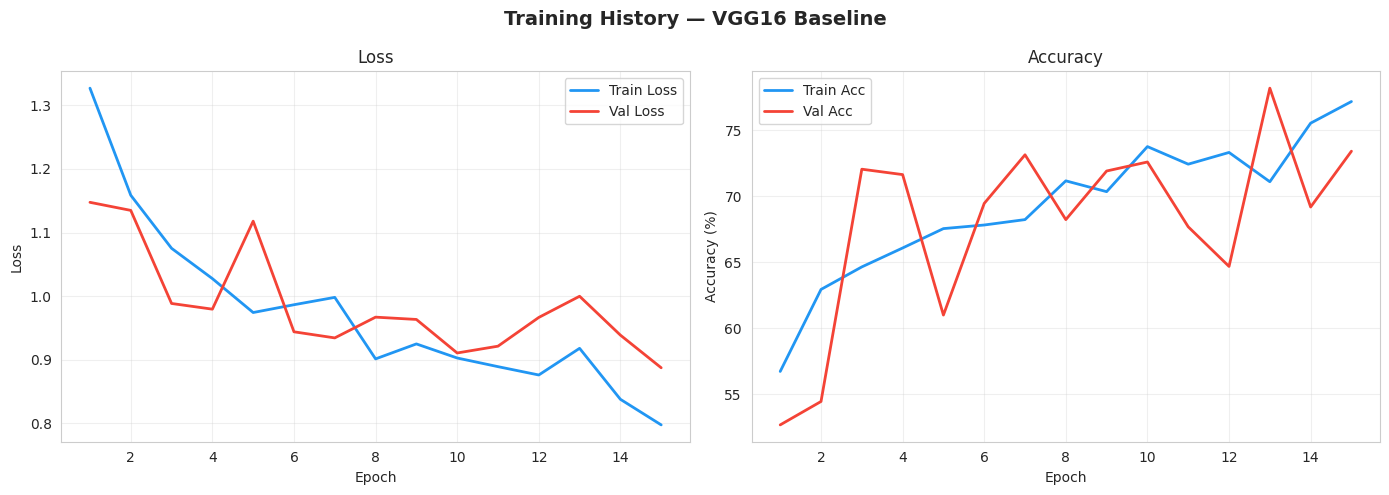

Saved → /kaggle/working/curves_vgg16_baseline.png
Final train accuracy : 77.16%
Final val accuracy   : 73.40%
Train-Val gap        : 3.76%


In [46]:
plot_training_curves(vgg16_history, "VGG16 Baseline")

final_tr = vgg16_history["train_acc"][-1] * 100
final_vl = vgg16_history["val_acc"][-1]  * 100
gap      = final_tr - final_vl

print(f"Final train accuracy : {final_tr:.2f}%")
print(f"Final val accuracy   : {final_vl:.2f}%")
print(f"Train-Val gap        : {gap:.2f}%")



  Evaluation Results — vgg16_baseline
  Accuracy          : 0.7340
  Weighted F1-Score : 0.7407   ← primary metric
  Quadratic Kappa   : 0.8417   ← official APTOS metric
  Mean AUC-ROC      : 0.9247

  Per-class AUC:
    Grade 0 (No DR          ): 0.9874
    Grade 1 (Mild           ): 0.9151
    Grade 2 (Moderate       ): 0.9156
    Grade 3 (Severe         ): 0.9226
    Grade 4 (Proliferative  ): 0.8828

  Classification Report:
               precision    recall  f1-score   support

        No DR       0.96      0.96      0.96       361
         Mild       0.45      0.68      0.54        74
     Moderate       0.76      0.48      0.59       200
       Severe       0.27      0.77      0.40        39
Proliferative       0.65      0.29      0.40        59

     accuracy                           0.73       733
    macro avg       0.62      0.63      0.58       733
 weighted avg       0.79      0.73      0.74       733



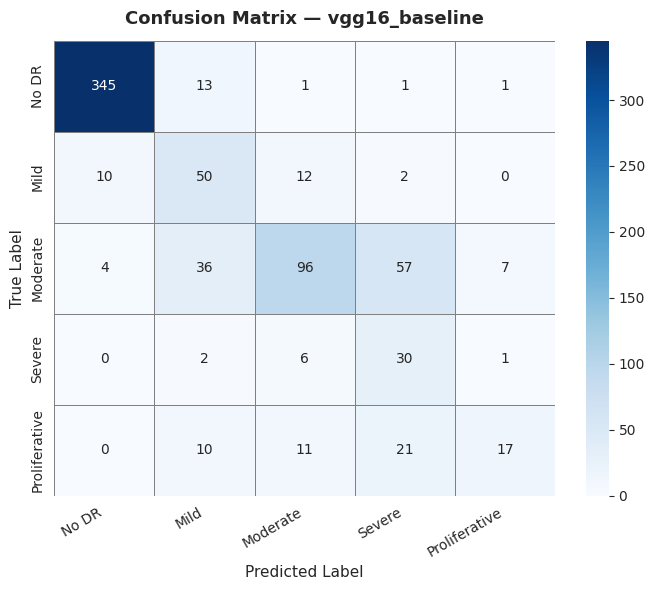

Saved confusion matrix → /kaggle/working/cm_vgg16_baseline.png

Results saved → /kaggle/working/results_log.json


In [47]:
vgg16_results = evaluate_model(
    model         = vgg16_model,
    architecture  = "vgg16",
    preprocess_name = "baseline",
    enhanced      = False
)
vgg16_results["train_time_min"] = round(vgg16_time / 60, 2)

results_log = [vgg16_results]
results_path = os.path.join(WORK_DIR, "results_log.json")
with open(results_path, "w") as f:
    json.dump(results_log, f, indent=2)

print(f"\nResults saved → {results_path}")

In [48]:
@torch.no_grad()
def get_predictions(model, enhanced=False):
    """Get all predictions and true labels for the validation set."""
    model.eval()
    _, val_loader = get_dataloaders(enhanced=enhanced)
    all_preds, all_labels = [], []
    for images, labels in val_loader:
        outputs = model(images.to(DEVICE))
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(vgg16_model, enhanced=False)

# Find misclassified samples
wrong_mask = y_true != y_pred

print(f"Total val samples     : {len(y_true)}")
print(f"Misclassified         : {wrong_mask.sum()} ({wrong_mask.mean()*100:.1f}%)")
print()

# Per-class recall
print("Per-class recall (how many of each grade did we get right):")
print(f"{'Grade':<5} {'Class':<18} {'Correct':>8} {'Total':>8} {'Recall':>8}")
print("-" * 50)
for g in range(NUM_CLASSES):
    mask    = y_true == g
    correct = ((y_true == g) & (y_pred == g)).sum()
    total   = mask.sum()
    recall  = correct / total if total > 0 else 0
    bar     = "█" * int(recall * 12)
    print(f"  {g}    {CLASS_NAMES[g]:<18} {correct:>8} {total:>8}   {recall:.3f}  {bar}")

print()
print("Most common mistakes (True → Predicted):")
from collections import Counter
pairs = Counter(zip(y_true[wrong_mask], y_pred[wrong_mask]))
for (t, p), count in pairs.most_common(6):
    print(f"  {CLASS_NAMES[t]:<15} → {CLASS_NAMES[p]:<15}  ({count} times)")


Total val samples     : 733
Misclassified         : 195 (26.6%)

Per-class recall (how many of each grade did we get right):
Grade Class               Correct    Total   Recall
--------------------------------------------------
  0    No DR                   345      361   0.956  ███████████
  1    Mild                     50       74   0.676  ████████
  2    Moderate                 96      200   0.480  █████
  3    Severe                   30       39   0.769  █████████
  4    Proliferative            17       59   0.288  ███

Most common mistakes (True → Predicted):
  Moderate        → Severe           (57 times)
  Moderate        → Mild             (36 times)
  Proliferative   → Severe           (21 times)
  No DR           → Mild             (13 times)
  Mild            → Moderate         (12 times)
  Proliferative   → Moderate         (11 times)
